In [1]:
# ============================================================
# 01_exploration.ipynb
# Exploration des données de stock SAGE
# Changer BASE_NAME pour analyser une autre base 
# ============================================================

# ── Cellule 1 : Configuration ────────────────────────────────
BASE_NAME = 'STE_NGDM'   # ← changer ici pour STE_NGDM ou autre base pour l'analyse 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sqlalchemy import create_engine, text
import pyodbc
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family']       = 'DejaVu Sans'
sns.set_palette('tab10')

print(f"✅ Configuration chargée — Base cible : {BASE_NAME}")

✅ Configuration chargée — Base cible : STE_NGDM


In [2]:
from sqlalchemy import create_engine, text

SERVER   = r'SALMAIKSOD\SAGE100'
DATABASE = 'Test'
USERNAME = 'sa'
PASSWORD = '123456'

# SQLAlchemy avec SQL Auth
conn_str = (
    f"mssql+pyodbc://{USERNAME}:{PASSWORD}@{SERVER}/{DATABASE}"
    f"?driver=ODBC+Driver+17+for+SQL+Server"
    f"&TrustServerCertificate=yes"
)

engine = create_engine(conn_str, fast_executemany=True)

# Test
with engine.connect() as conn:
    r = conn.execute(text("SELECT DB_NAME() AS db")).fetchone()
    print(f"✅ Connexion SQLAlchemy OK — Base active : {r.db}")

✅ Connexion SQLAlchemy OK — Base active : Test


In [3]:
import os
os.makedirs('../outputs', exist_ok=True)

query = text("""
SELECT 
    BaseName, DateJour, AR_Ref, AR_Design,
    FA_CodeFamille, FA_Intitule,
    CL_No1, CL_Intitule1,
    DE_No, DE_Intitule,
    TotalEntree, TotalSortie,
    ValeurEntree, ValeurSortie,
    StockFinal, ValeurFinale
FROM Test.stock.VW_StockJoursAvecMvt
WHERE BaseName = :base
ORDER BY AR_Ref, DE_No, DateJour
""")

with engine.connect() as conn:
    df_raw = pd.read_sql(query, conn, params={'base': BASE_NAME})

# Types
df_raw['DateJour']     = pd.to_datetime(df_raw['DateJour'])
df_raw['DE_No']        = pd.to_numeric(df_raw['DE_No'],        errors='coerce').fillna(0).astype(int)
df_raw['TotalEntree']  = pd.to_numeric(df_raw['TotalEntree'],  errors='coerce').fillna(0)
df_raw['TotalSortie']  = pd.to_numeric(df_raw['TotalSortie'],  errors='coerce').fillna(0)
df_raw['ValeurEntree'] = pd.to_numeric(df_raw['ValeurEntree'], errors='coerce').fillna(0)
df_raw['ValeurSortie'] = pd.to_numeric(df_raw['ValeurSortie'], errors='coerce').fillna(0)
df_raw['StockFinal']   = pd.to_numeric(df_raw['StockFinal'],   errors='coerce').fillna(0)
df_raw['ValeurFinale'] = pd.to_numeric(df_raw['ValeurFinale'], errors='coerce').fillna(0)

print(f"✅ Données chargées")
print(f"   Lignes           : {len(df_raw):,}")
print(f"   Articles uniques : {df_raw['AR_Ref'].nunique():,}")
print(f"   Dépôts uniques   : {df_raw['DE_No'].nunique():,}")
print(f"   Période          : {df_raw['DateJour'].min().date()} → {df_raw['DateJour'].max().date()}")
print(f"   Jours couverts   : {df_raw['DateJour'].nunique():,}")
df_raw.head(3)

✅ Données chargées
   Lignes           : 16,972
   Articles uniques : 278
   Dépôts uniques   : 12
   Période          : 2022-12-31 → 2025-10-01
   Jours couverts   : 586


,BaseName,DateJour,AR_Ref,AR_Design,FA_CodeFamille,FA_Intitule,CL_No1,CL_Intitule1,DE_No,DE_Intitule,TotalEntree,TotalSortie,ValeurEntree,ValeurSortie,StockFinal,ValeurFinale
0,STE_NGDM,2024-07-24,000066,TIFFANY CHUNKOS 40G CHOCOLATE(*60),TIFFANY,TIFFANY,14,TIFFANY,8,TIFFANYCASA,2029.0,0.0,150957.6,0.0,2029.0,150957.6
1,STE_NGDM,2024-07-29,000066,TIFFANY CHUNKOS 40G CHOCOLATE(*60),TIFFANY,TIFFANY,14,TIFFANY,8,TIFFANYCASA,0.0,50.0,0.0,4000.0,1979.0,146957.6
2,STE_NGDM,2024-07-30,000066,TIFFANY CHUNKOS 40G CHOCOLATE(*60),TIFFANY,TIFFANY,14,TIFFANY,8,TIFFANYCASA,0.0,295.0,0.0,23600.0,1684.0,123357.6


In [4]:
print("=" * 60)
print(f"RAPPORT QUALITÉ — {BASE_NAME}")
print("=" * 60)

# Valeurs manquantes
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
df_missing = pd.DataFrame({
    'Manquants': missing,
    'Pourcentage %': missing_pct
}).query('Manquants > 0')

if df_missing.empty:
    print("\n✅ Aucune valeur manquante")
else:
    print("\n⚠️  Valeurs manquantes :")
    print(df_missing.to_string())

# Stats des colonnes clés
print(f"\n📊 Statistiques clés :")
cols_stats = ['TotalEntree', 'TotalSortie', 'ValeurEntree', 'ValeurSortie', 'StockFinal', 'ValeurFinale']
print(df_raw[cols_stats].describe().round(2).to_string())

# Lignes avec sorties nulles
pct_zero_sortie = (df_raw['TotalSortie'] == 0).mean() * 100
print(f"\n   Jours sans sortie : {pct_zero_sortie:.1f}%")
print(f"   Jours avec sortie : {100 - pct_zero_sortie:.1f}%")

RAPPORT QUALITÉ — STE_NGDM

✅ Aucune valeur manquante

📊 Statistiques clés :
       TotalEntree  TotalSortie  ValeurEntree  ValeurSortie  StockFinal  ValeurFinale
count     16972.00     16972.00      16972.00      16972.00    16972.00      16972.00
mean        136.57       127.99       9564.34       9319.99     1462.79      52978.37
std         738.21       337.26      48929.78      29118.86     2564.52     152143.92
min           0.00         0.00          0.00          0.00    -6203.00    -339667.77
25%           0.00         3.00          0.00        314.16       66.66        229.50
50%           0.00        20.00          0.00       1125.00      410.79      14915.38
75%           0.00       114.00          0.00       6014.37     1608.37      53978.56
max       20447.95     12070.86    1745232.53    1031990.53    32847.40    2786967.23

   Jours sans sortie : 10.9%
   Jours avec sortie : 89.1%


Articles prévisibles  (>= 60j) : 95
Articles non prévisibles (< 60j) : 183
Total                               : 278


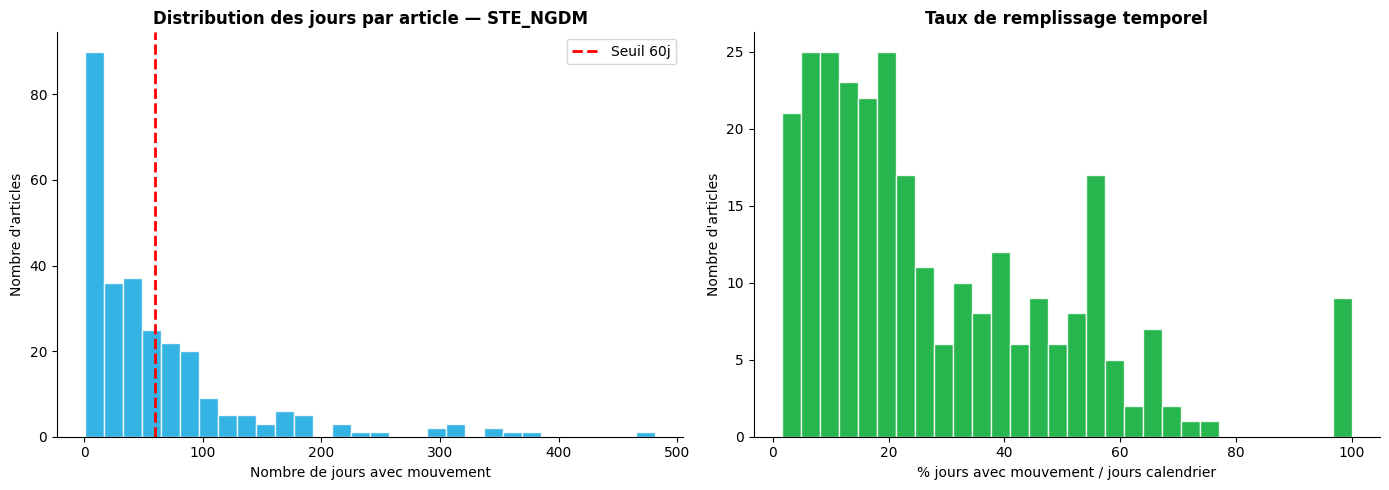

✅ Graphique sauvegardé


In [5]:
hist = (
    df_raw.groupby('AR_Ref')['DateJour']
    .agg(nb_jours='count', date_min='min', date_max='max')
    .assign(
        jours_cal=lambda x: (x['date_max'] - x['date_min']).dt.days + 1,
        taux_remplissage=lambda x: (x['nb_jours'] / x['jours_cal'] * 100).round(1)
    )
    .sort_values('nb_jours', ascending=False)
    .reset_index()
)

seuil = 60
n_ok = (hist['nb_jours'] >= seuil).sum()
n_ko = (hist['nb_jours'] <  seuil).sum()

print(f"Articles prévisibles  (>= {seuil}j) : {n_ok}")
print(f"Articles non prévisibles (< {seuil}j) : {n_ko}")
print(f"Total                               : {len(hist)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(hist['nb_jours'], bins=30, color='#12a6e0', edgecolor='white', alpha=0.85)
axes[0].axvline(seuil, color='red', linestyle='--', linewidth=2, label=f'Seuil {seuil}j')
axes[0].set_title(f'Distribution des jours par article — {BASE_NAME}', fontweight='bold')
axes[0].set_xlabel("Nombre de jours avec mouvement")
axes[0].set_ylabel("Nombre d'articles")
axes[0].legend()

axes[1].hist(hist['taux_remplissage'], bins=30, color='#01a82e', edgecolor='white', alpha=0.85)
axes[1].set_title('Taux de remplissage temporel', fontweight='bold')
axes[1].set_xlabel("% jours avec mouvement / jours calendrier")
axes[1].set_ylabel("Nombre d'articles")

plt.tight_layout()
plt.savefig(f'../outputs/{BASE_NAME}_01_historique.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Graphique sauvegardé")

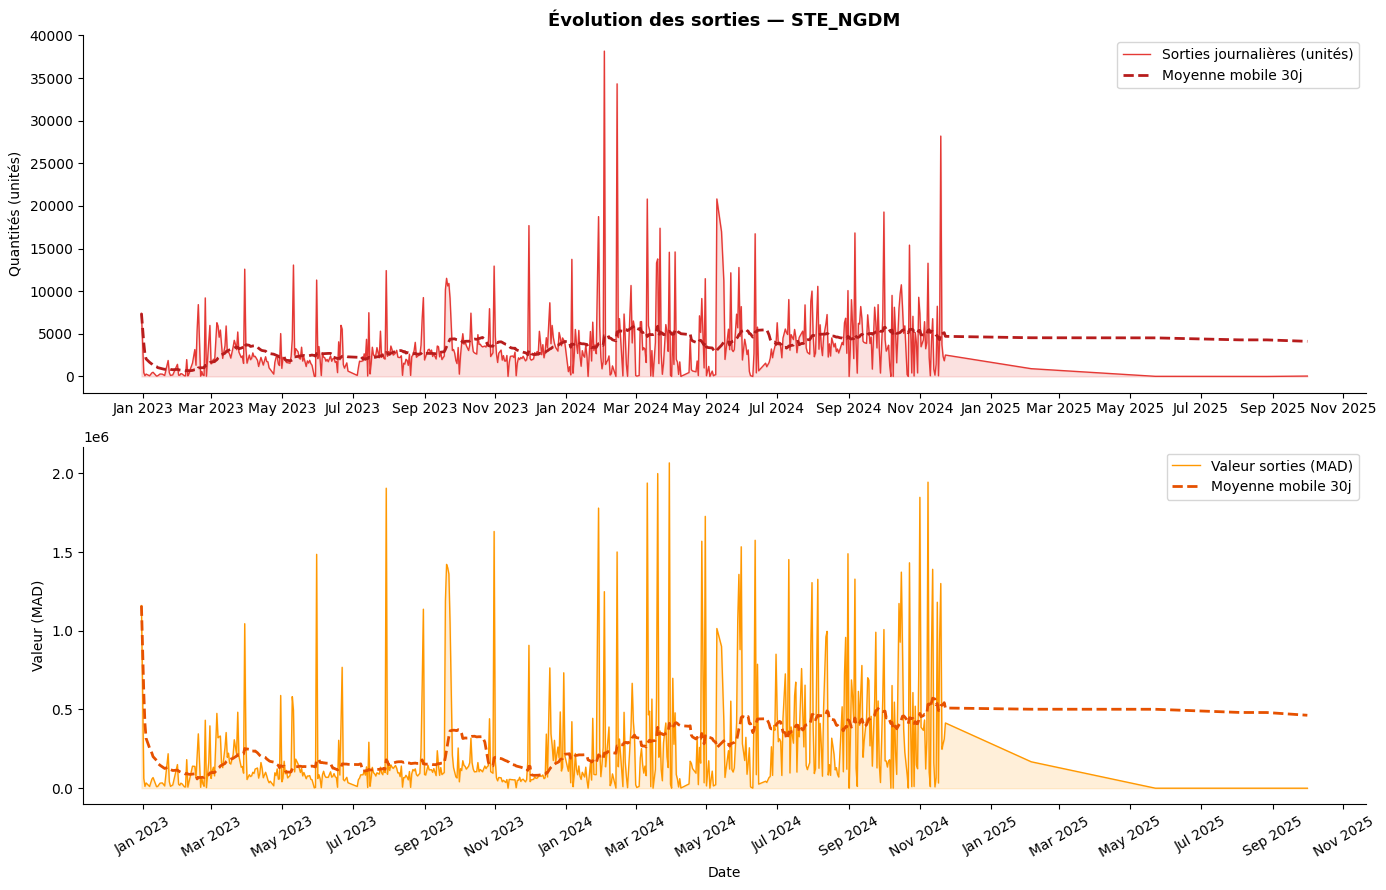

In [6]:
sorties_jour = (
    df_raw.groupby('DateJour')[['TotalSortie', 'ValeurSortie']]
    .sum()
    .reset_index()
)
sorties_jour['ma30_qte']    = sorties_jour['TotalSortie'].rolling(30, min_periods=1).mean()
sorties_jour['ma30_valeur'] = sorties_jour['ValeurSortie'].rolling(30, min_periods=1).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Quantités
axes[0].fill_between(sorties_jour['DateJour'], sorties_jour['TotalSortie'],
                     alpha=0.15, color='#e53935')
axes[0].plot(sorties_jour['DateJour'], sorties_jour['TotalSortie'],
             color='#e53935', linewidth=1, label='Sorties journalières (unités)')
axes[0].plot(sorties_jour['DateJour'], sorties_jour['ma30_qte'],
             color='#b71c1c', linewidth=2, linestyle='--', label='Moyenne mobile 30j')
axes[0].set_title(f'Évolution des sorties — {BASE_NAME}', fontweight='bold', fontsize=13)
axes[0].set_ylabel("Quantités (unités)")
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

# Valeurs MAD
axes[1].fill_between(sorties_jour['DateJour'], sorties_jour['ValeurSortie'],
                     alpha=0.15, color='#ff9800')
axes[1].plot(sorties_jour['DateJour'], sorties_jour['ValeurSortie'],
             color='#ff9800', linewidth=1, label='Valeur sorties (MAD)')
axes[1].plot(sorties_jour['DateJour'], sorties_jour['ma30_valeur'],
             color='#e65100', linewidth=2, linestyle='--', label='Moyenne mobile 30j')
axes[1].set_ylabel("Valeur (MAD)")
axes[1].set_xlabel("Date")
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'../outputs/{BASE_NAME}_02_sorties_globales.png', dpi=150, bbox_inches='tight')
plt.show()

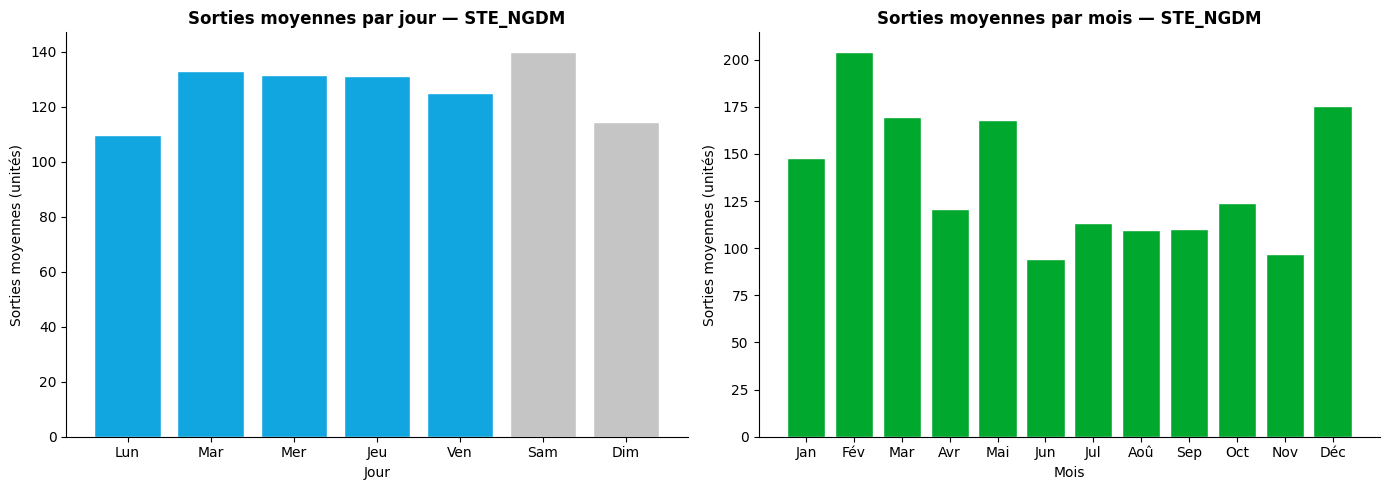

In [7]:
df_raw['jour_semaine']  = df_raw['DateJour'].dt.dayofweek
df_raw['nom_jour']      = df_raw['DateJour'].dt.day_name()
df_raw['mois']          = df_raw['DateJour'].dt.month

ordre_jours  = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
labels_fr    = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']
colors_week  = ['#12a6e0']*5 + ['#c5c5c5']*2

sorties_sem = (
    df_raw.groupby('nom_jour')['TotalSortie']
    .mean()
    .reindex(ordre_jours)
)

noms_mois_fr = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']
sorties_mois = df_raw.groupby('mois')['TotalSortie'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(labels_fr, sorties_sem.values, color=colors_week, edgecolor='white')
axes[0].set_title(f'Sorties moyennes par jour — {BASE_NAME}', fontweight='bold')
axes[0].set_xlabel("Jour"); axes[0].set_ylabel("Sorties moyennes (unités)")

axes[1].bar(
    [noms_mois_fr[m-1] for m in sorties_mois.index],
    sorties_mois.values,
    color='#01a82e', edgecolor='white'
)
axes[1].set_title(f'Sorties moyennes par mois — {BASE_NAME}', fontweight='bold')
axes[1].set_xlabel("Mois"); axes[1].set_ylabel("Sorties moyennes (unités)")

plt.tight_layout()
plt.savefig(f'../outputs/{BASE_NAME}_03_saisonnalite.png', dpi=150, bbox_inches='tight')
plt.show()

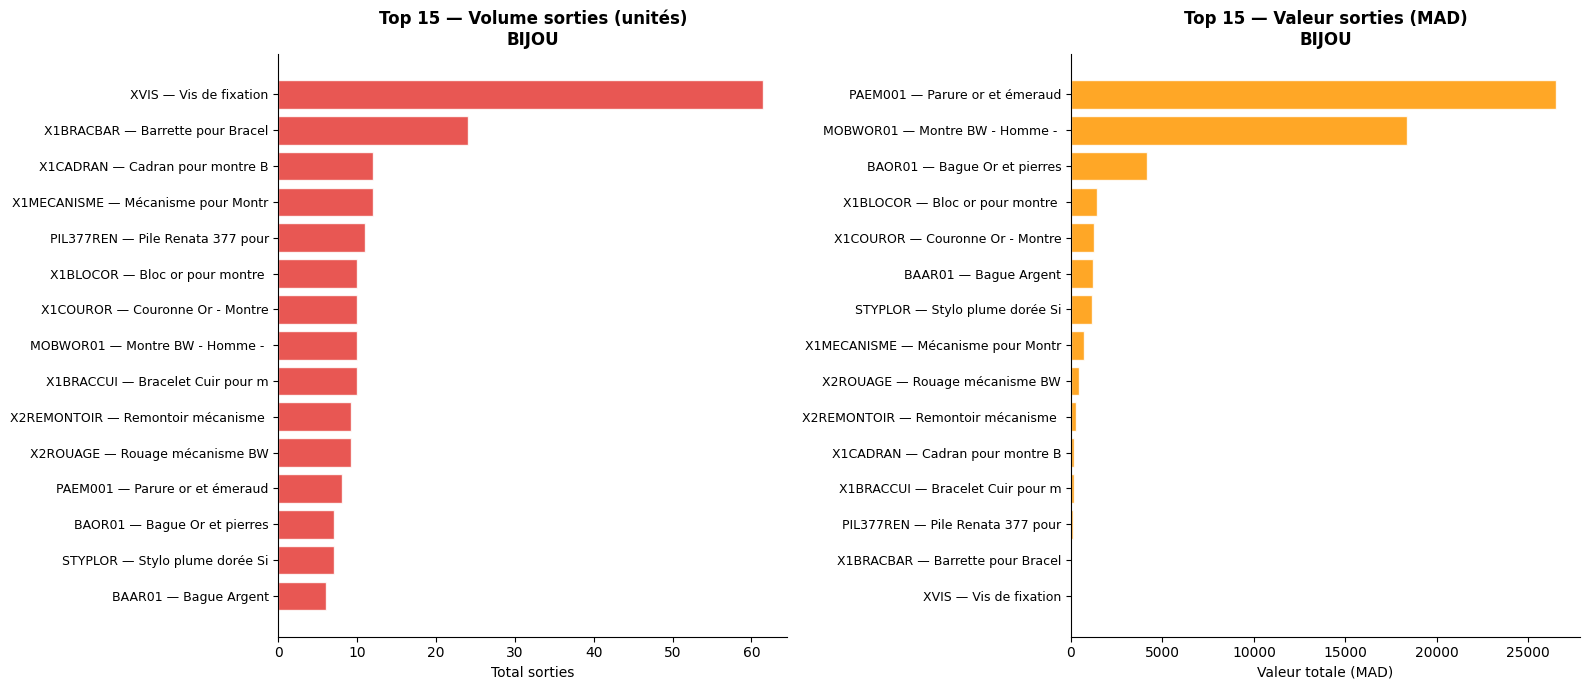

     AR_Ref                        AR_Design  total_sortie_qte  total_sortie_val  nb_jours
       XVIS                  Vis de fixation             61.50              5.55         3
  X1BRACBAR Barrette pour Bracelet montre BW             24.00             21.60         2
   X1CADRAN            Cadran pour montre BW             12.00            141.60         2
X1MECANISME         Mécanisme pour Montre BW             12.00            734.64         3
  PIL377REN     Pile Renata 377 pour montres             11.00            113.75         4
   X1BLOCOR           Bloc or pour montre BW             10.00           1450.00         2
   X1COUROR  Couronne Or - Montre BW Bloc Or             10.00           1233.00         2
   MOBWOR01      Montre BW - Homme - Bloc Or             10.00          18345.30         2
  X1BRACCUI     Bracelet Cuir pour montre BW             10.00            140.00         2
X2REMONTOIR           Remontoir mécanisme BW              9.25            261.78         2

In [8]:
top_art = (
    df_raw.groupby(['AR_Ref', 'AR_Design'])
    .agg(
        total_sortie_qte=('TotalSortie',   'sum'),
        total_sortie_val=('ValeurSortie',  'sum'),
        nb_jours=        ('DateJour',      'count')
    )
    .sort_values('total_sortie_qte', ascending=False)
    .head(15)
    .reset_index()
)
top_art['label'] = top_art['AR_Ref'] + ' — ' + top_art['AR_Design'].str[:20]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Par quantité
axes[0].barh(range(len(top_art)), top_art['total_sortie_qte'],
             color='#e53935', edgecolor='white', alpha=0.85)
axes[0].set_yticks(range(len(top_art)))
axes[0].set_yticklabels(top_art['label'], fontsize=9)
axes[0].invert_yaxis()
axes[0].set_title(f'Top 15 — Volume sorties (unités)\n{BASE_NAME}', fontweight='bold')
axes[0].set_xlabel("Total sorties")

# Par valeur MAD
top_val = top_art.sort_values('total_sortie_val', ascending=False)
axes[1].barh(range(len(top_val)), top_val['total_sortie_val'],
             color='#ff9800', edgecolor='white', alpha=0.85)
axes[1].set_yticks(range(len(top_val)))
axes[1].set_yticklabels(top_val['label'], fontsize=9)
axes[1].invert_yaxis()
axes[1].set_title(f'Top 15 — Valeur sorties (MAD)\n{BASE_NAME}', fontweight='bold')
axes[1].set_xlabel("Valeur totale (MAD)")

plt.tight_layout()
plt.savefig(f'../outputs/{BASE_NAME}_04_top_articles.png', dpi=150, bbox_inches='tight')
plt.show()

print(top_art[['AR_Ref', 'AR_Design', 'total_sortie_qte', 'total_sortie_val', 'nb_jours']].to_string(index=False))

Articles avec stock minimum <= 0 : 249
Articles ayant été à zéro (>= 1j): 249
Articles à risque élevé (>= 5j)  : 82


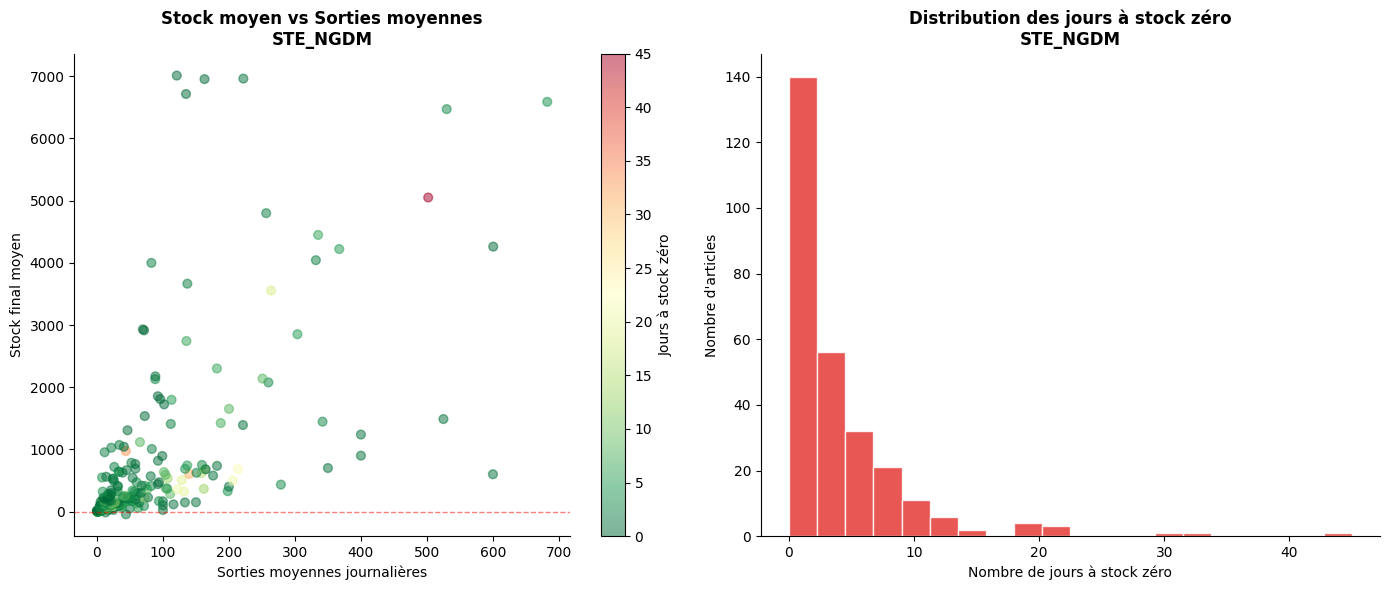

In [8]:
stock_analyse = (
    df_raw.groupby(['AR_Ref', 'AR_Design'])
    .agg(
        stock_moyen=     ('StockFinal',   'mean'),
        stock_min=       ('StockFinal',   'min'),
        stock_max=       ('StockFinal',   'max'),
        sorties_moy=     ('TotalSortie',  'mean'),
        nb_jours_zero=   ('StockFinal',   lambda x: (x <= 0).sum()),
        valeur_moy=      ('ValeurFinale', 'mean')
    )
    .reset_index()
    .sort_values('stock_moyen')
)

print(f"Articles avec stock minimum <= 0 : {(stock_analyse['stock_min'] <= 0).sum()}")
print(f"Articles ayant été à zéro (>= 1j): {(stock_analyse['nb_jours_zero'] > 0).sum()}")
print(f"Articles à risque élevé (>= 5j)  : {(stock_analyse['nb_jours_zero'] >= 5).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc = axes[0].scatter(
    stock_analyse['sorties_moy'],
    stock_analyse['stock_moyen'],
    c=stock_analyse['nb_jours_zero'],
    cmap='RdYlGn_r', alpha=0.5, s=40
)
plt.colorbar(sc, ax=axes[0], label='Jours à stock zéro')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_title(f'Stock moyen vs Sorties moyennes\n{BASE_NAME}', fontweight='bold')
axes[0].set_xlabel("Sorties moyennes journalières")
axes[0].set_ylabel("Stock final moyen")

axes[1].hist(stock_analyse['nb_jours_zero'], bins=20,
             color='#e53935', edgecolor='white', alpha=0.85)
axes[1].set_title(f'Distribution des jours à stock zéro\n{BASE_NAME}', fontweight='bold')
axes[1].set_xlabel("Nombre de jours à stock zéro")
axes[1].set_ylabel("Nombre d'articles")

plt.tight_layout()
plt.savefig(f'../outputs/{BASE_NAME}_05_risques_rupture.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
articles_previsibles = hist[hist['nb_jours'] >= 60][['AR_Ref', 'nb_jours']]
articles_risque      = stock_analyse[stock_analyse['nb_jours_zero'] >= 5]

print("=" * 60)
print(f"RÉSUMÉ EXPLORATION — {BASE_NAME}")
print("=" * 60)
print(f"\n📦 Articles total              : {df_raw['AR_Ref'].nunique()}")
print(f"✅ Prévisibles (>= 60j mvt)    : {len(articles_previsibles)}")
print(f"❌ Non prévisibles (<  60j)    : {df_raw['AR_Ref'].nunique() - len(articles_previsibles)}")
print(f"🔴 Articles à risque rupture   : {len(articles_risque)}")
print(f"🏪 Dépôts                      : {df_raw['DE_No'].nunique()}")
print(f"\n📅 Période                     : {df_raw['DateJour'].min().date()} → {df_raw['DateJour'].max().date()}")
print(f"📈 Jours avec mouvement        : {df_raw['DateJour'].nunique()}")
print(f"💰 Valeur totale sorties (MAD) : {df_raw['ValeurSortie'].sum():,.2f}")

# Sauvegarder pour notebook 02
df_raw.to_parquet(f'../outputs/{BASE_NAME}_raw.parquet', index=False)
articles_previsibles.to_csv(f'../outputs/{BASE_NAME}_articles_previsibles.csv', index=False)

print(f"\n✅ Données sauvegardées dans outputs/")
print(f"   → {BASE_NAME}_raw.parquet")
print(f"   → {BASE_NAME}_articles_previsibles.csv")

RÉSUMÉ EXPLORATION — STE_NGDM

📦 Articles total              : 278
✅ Prévisibles (>= 60j mvt)    : 95
❌ Non prévisibles (<  60j)    : 183
🔴 Articles à risque rupture   : 82
🏪 Dépôts                      : 12

📅 Période                     : 2022-12-31 → 2025-10-01
📈 Jours avec mouvement        : 586
💰 Valeur totale sorties (MAD) : 158,178,863.52

✅ Données sauvegardées dans outputs/
   → STE_NGDM_raw.parquet
   → STE_NGDM_articles_previsibles.csv


In [11]:
# ── Cellule A : Structure et types des données ────────────────
print("=" * 60)
print(f"STRUCTURE DES DONNÉES — {BASE_NAME}")
print("=" * 60)

print(f"\n📋 Types de colonnes :")
types_info = pd.DataFrame({
    'Colonne':      df_raw.dtypes.index,
    'Type Python':  df_raw.dtypes.values,
    'Exemple':      [df_raw[c].dropna().iloc[0] if len(df_raw[c].dropna()) > 0 else 'N/A'
                     for c in df_raw.columns],
    'Valeurs nulles': df_raw.isnull().sum().values,
    'Valeurs uniques': df_raw.nunique().values
})
print(types_info.to_string(index=False))

print(f"\n📊 Plages de valeurs :")
cols_num = ['TotalEntree','TotalSortie','ValeurEntree','ValeurSortie','StockFinal','ValeurFinale']
for col in cols_num:
    print(f"   {col:<20} : min={df_raw[col].min():>12,.2f}  "
          f"max={df_raw[col].max():>15,.2f}  "
          f"moy={df_raw[col].mean():>12,.2f}  "
          f"zeros={( df_raw[col]==0).sum():>5}")

STRUCTURE DES DONNÉES — STE_NGDM

📋 Types de colonnes :
       Colonne   Type Python                            Exemple  Valeurs nulles  Valeurs uniques
      BaseName           str                           STE_NGDM               0                1
      DateJour datetime64[s]                2024-07-24 00:00:00               0              586
        AR_Ref           str                             000066               0              278
     AR_Design           str TIFFANY CHUNKOS 40G CHOCOLATE(*60)               0              278
FA_CodeFamille           str                            TIFFANY               0               38
   FA_Intitule           str                            TIFFANY               0               38
        CL_No1         int64                                 14               0               11
  CL_Intitule1           str                            TIFFANY               0               11
         DE_No         int64                                  8        

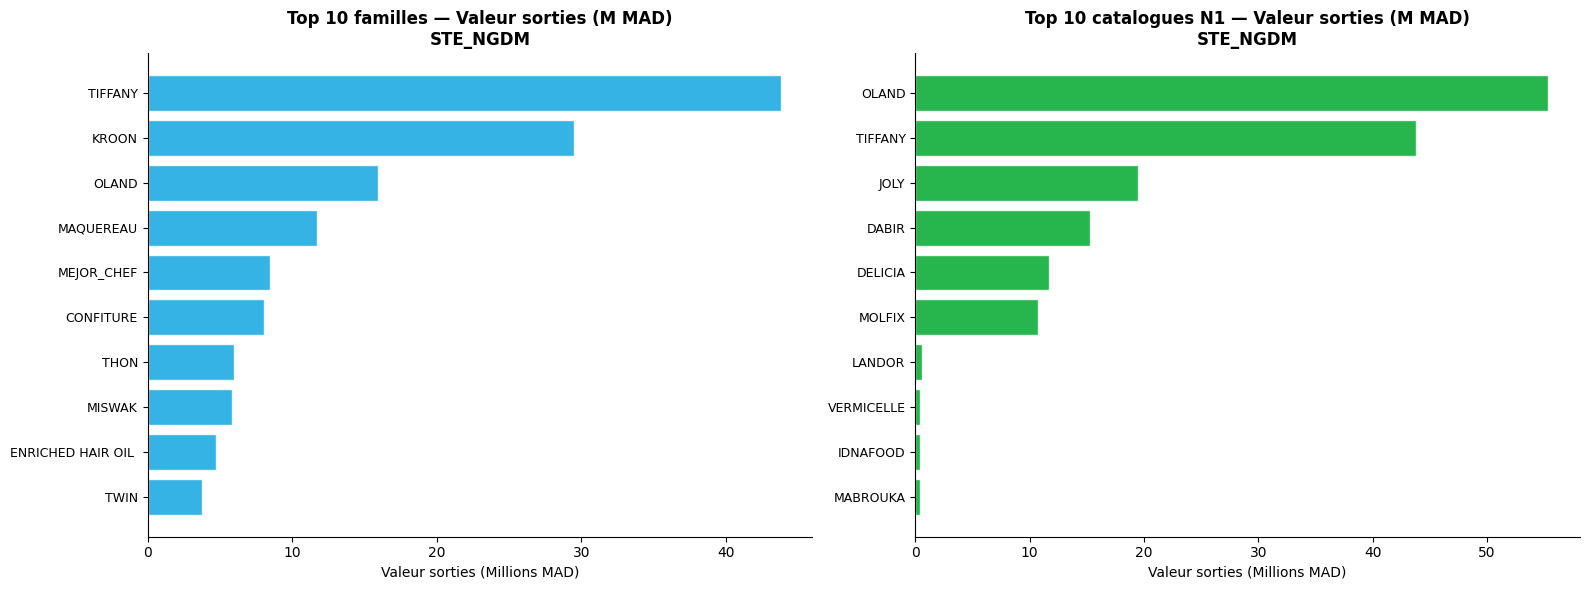

Top 10 familles par valeur :
       FA_Intitule  nb_articles  total_sortie  valeur_sortie
           TIFFANY           22     244009.57    43788610.94
             KROON            8     355908.81    29454880.27
             OLAND           31     788551.43    15957392.15
         MAQUEREAU           16      56960.54    11734124.47
        MEJOR_CHEF            5     241366.50     8450985.08
         CONFITURE           15      76363.41     8031617.83
              THON           21      28894.25     5958541.48
            MISWAK            8      11657.65     5824265.22
ENRICHED HAIR OIL            14      11761.90     4741030.41
              TWIN            5      23505.00     3748943.22


In [13]:
# ── Cellule B : Répartition par famille et catalogue ──────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Par famille
famille_stats = (
    df_raw.groupby('FA_Intitule')
    .agg(
        nb_articles=  ('AR_Ref',       'nunique'),
        total_sortie= ('TotalSortie',  'sum'),
        valeur_sortie=('ValeurSortie', 'sum')
    )
    .sort_values('valeur_sortie', ascending=False)
    .head(10)
    .reset_index()
)

famille_stats['FA_Intitule_court'] = famille_stats['FA_Intitule'].str[:25]

axes[0].barh(range(len(famille_stats)),
             famille_stats['valeur_sortie'] / 1e6,
             color='#12a6e0', edgecolor='white', alpha=0.85)
axes[0].set_yticks(range(len(famille_stats)))
axes[0].set_yticklabels(famille_stats['FA_Intitule_court'], fontsize=9)
axes[0].invert_yaxis()
axes[0].set_title(f'Top 10 familles — Valeur sorties (M MAD)\n{BASE_NAME}',
                  fontweight='bold')
axes[0].set_xlabel("Valeur sorties (Millions MAD)")

# Par catalogue N1
cat1_stats = (
    df_raw.groupby('CL_Intitule1')
    .agg(
        nb_articles=  ('AR_Ref',       'nunique'),
        total_sortie= ('TotalSortie',  'sum'),
        valeur_sortie=('ValeurSortie', 'sum')
    )
    .sort_values('valeur_sortie', ascending=False)
    .head(10)
    .reset_index()
    .fillna({'CL_Intitule1': 'Sans catalogue'})
)
cat1_stats['CL_Intitule1_court'] = cat1_stats['CL_Intitule1'].fillna('N/A').str[:25]

axes[1].barh(range(len(cat1_stats)),
             cat1_stats['valeur_sortie'] / 1e6,
             color='#01a82e', edgecolor='white', alpha=0.85)
axes[1].set_yticks(range(len(cat1_stats)))
axes[1].set_yticklabels(cat1_stats['CL_Intitule1_court'], fontsize=9)
axes[1].invert_yaxis()
axes[1].set_title(f'Top 10 catalogues N1 — Valeur sorties (M MAD)\n{BASE_NAME}',
                  fontweight='bold')
axes[1].set_xlabel("Valeur sorties (Millions MAD)")

plt.tight_layout()
plt.savefig(f'../outputs/{BASE_NAME}_06_famille_catalogue.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 familles par valeur :")
print(famille_stats[['FA_Intitule','nb_articles',
                      'total_sortie','valeur_sortie']].to_string(index=False))

ANALYSE PAR DÉPÔT — STE_NGDM
 DE_No    DE_Intitule  nb_articles  total_sortie  valeur_sortie   stock_moy  nb_jours_actif
     6          OLAND           54    1564668.79    55163637.66 2577.365566             516
     2      JOLY NGDM           82     223604.10    31970635.32  498.083325             213
     8    TIFFANYCASA           25     159868.30    28270193.23 1328.528731             142
     9   TIFFANYRABAT           25      86547.44    15849410.44  555.437960             173
    11    DABUR RABAT           85      41072.67    11922704.36  329.192423             127
    12    MOLFIX CASA           26      72144.48    10712856.34 1749.848731              95
    15     DABUR CASA           68      12560.82     2685947.52   75.343070              56
    13   DABUR TANGER           82       1934.26      677499.31   34.046719              43
    14         LANDOR            8       3545.29      632136.01  236.132105              12
     3       OLAND NC           27       5560.95   

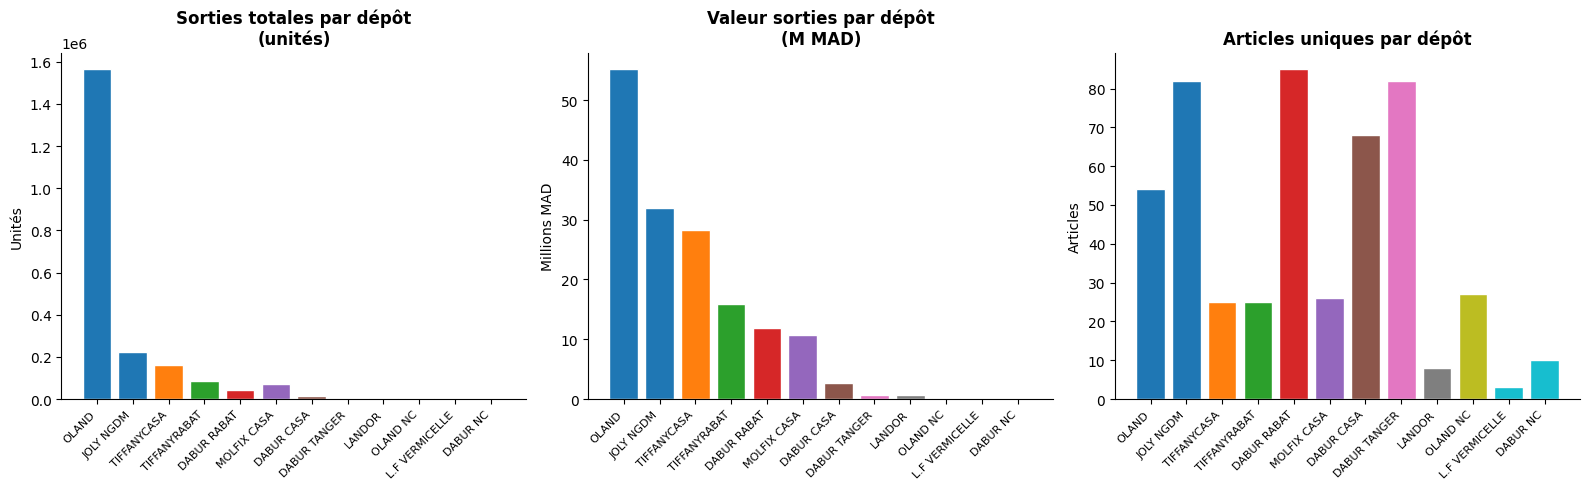

In [14]:
# ── Cellule C : Analyse par dépôt ─────────────────────────────
depot_stats = (
    df_raw.groupby(['DE_No', 'DE_Intitule'])
    .agg(
        nb_articles=    ('AR_Ref',       'nunique'),
        total_entree=   ('TotalEntree',  'sum'),
        total_sortie=   ('TotalSortie',  'sum'),
        valeur_entree=  ('ValeurEntree', 'sum'),
        valeur_sortie=  ('ValeurSortie', 'sum'),
        stock_moy=      ('StockFinal',   'mean'),
        nb_jours_actif= ('DateJour',     'nunique')
    )
    .reset_index()
    .sort_values('valeur_sortie', ascending=False)
)

print("=" * 60)
print(f"ANALYSE PAR DÉPÔT — {BASE_NAME}")
print("=" * 60)
print(depot_stats[['DE_No','DE_Intitule','nb_articles',
                   'total_sortie','valeur_sortie',
                   'stock_moy','nb_jours_actif']].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

depot_labels = depot_stats['DE_Intitule'].str[:15]
colors_depot = plt.cm.tab10(np.linspace(0, 1, len(depot_stats)))

# Sorties par dépôt
axes[0].bar(range(len(depot_stats)), depot_stats['total_sortie'],
            color=colors_depot, edgecolor='white')
axes[0].set_xticks(range(len(depot_stats)))
axes[0].set_xticklabels(depot_labels, rotation=45, ha='right', fontsize=8)
axes[0].set_title('Sorties totales par dépôt\n(unités)', fontweight='bold')
axes[0].set_ylabel("Unités")

# Valeur par dépôt
axes[1].bar(range(len(depot_stats)), depot_stats['valeur_sortie'] / 1e6,
            color=colors_depot, edgecolor='white')
axes[1].set_xticks(range(len(depot_stats)))
axes[1].set_xticklabels(depot_labels, rotation=45, ha='right', fontsize=8)
axes[1].set_title('Valeur sorties par dépôt\n(M MAD)', fontweight='bold')
axes[1].set_ylabel("Millions MAD")

# Articles par dépôt
axes[2].bar(range(len(depot_stats)), depot_stats['nb_articles'],
            color=colors_depot, edgecolor='white')
axes[2].set_xticks(range(len(depot_stats)))
axes[2].set_xticklabels(depot_labels, rotation=45, ha='right', fontsize=8)
axes[2].set_title("Articles uniques par dépôt", fontweight='bold')
axes[2].set_ylabel("Articles")

plt.tight_layout()
plt.savefig(f'../outputs/{BASE_NAME}_07_depots.png', dpi=150, bbox_inches='tight')
plt.show()

ÉVOLUTION ANNUELLE — STE_NGDM
 annee  total_sortie_qte  total_sortie_val  total_entree_qte  nb_articles_actifs  nb_jours_actifs
  2022           7411.90        1159993.35          37133.80                  65                1
  2023         869985.27       51217108.03         869933.60                 112              305
  2024        1293814.31      105633831.14        1410764.13                 227              275
  2025            967.62         167931.00              2.00                  37                5


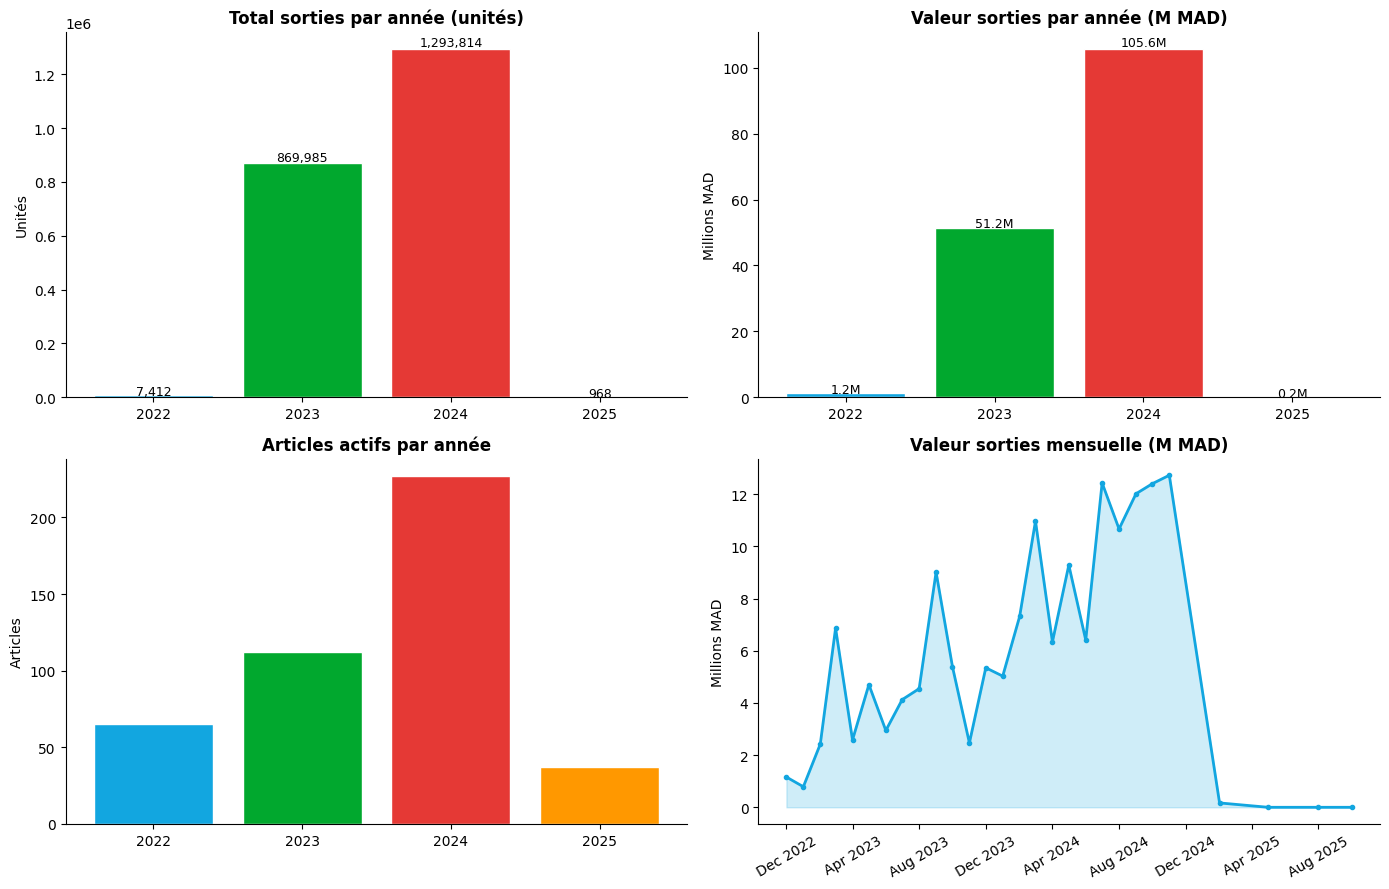

In [15]:
# ── Cellule D : Évolution annuelle ────────────────────────────
df_raw['annee']       = df_raw['DateJour'].dt.year
df_raw['annee_mois']  = df_raw['DateJour'].dt.to_period('M')

# Par année
annee_stats = (
    df_raw.groupby('annee')
    .agg(
        total_sortie_qte= ('TotalSortie',  'sum'),
        total_sortie_val= ('ValeurSortie', 'sum'),
        total_entree_qte= ('TotalEntree',  'sum'),
        nb_articles_actifs=('AR_Ref',      'nunique'),
        nb_jours_actifs=  ('DateJour',     'nunique')
    )
    .reset_index()
)

print("=" * 60)
print(f"ÉVOLUTION ANNUELLE — {BASE_NAME}")
print("=" * 60)
print(annee_stats.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

annees = annee_stats['annee'].astype(str)
colors_ann = ['#12a6e0', '#01a82e', '#e53935', '#ff9800'][:len(annee_stats)]

# Sorties quantité par année
axes[0,0].bar(annees, annee_stats['total_sortie_qte'],
              color=colors_ann, edgecolor='white')
axes[0,0].set_title('Total sorties par année (unités)', fontweight='bold')
axes[0,0].set_ylabel("Unités")
for i, v in enumerate(annee_stats['total_sortie_qte']):
    axes[0,0].text(i, v + v*0.01, f'{v:,.0f}', ha='center', fontsize=9)

# Valeur sorties par année
axes[0,1].bar(annees, annee_stats['total_sortie_val'] / 1e6,
              color=colors_ann, edgecolor='white')
axes[0,1].set_title('Valeur sorties par année (M MAD)', fontweight='bold')
axes[0,1].set_ylabel("Millions MAD")
for i, v in enumerate(annee_stats['total_sortie_val']):
    axes[0,1].text(i, v/1e6 + v/1e6*0.01, f'{v/1e6:.1f}M', ha='center', fontsize=9)

# Articles actifs par année
axes[1,0].bar(annees, annee_stats['nb_articles_actifs'],
              color=colors_ann, edgecolor='white')
axes[1,0].set_title('Articles actifs par année', fontweight='bold')
axes[1,0].set_ylabel("Articles")

# Évolution mensuelle sur toute la période
mensuel = (
    df_raw.groupby('annee_mois')['ValeurSortie']
    .sum()
    .reset_index()
)
mensuel['annee_mois_dt'] = mensuel['annee_mois'].dt.to_timestamp()

axes[1,1].fill_between(mensuel['annee_mois_dt'],
                       mensuel['ValeurSortie'] / 1e6,
                       alpha=0.2, color='#12a6e0')
axes[1,1].plot(mensuel['annee_mois_dt'],
               mensuel['ValeurSortie'] / 1e6,
               color='#12a6e0', linewidth=2, marker='o', markersize=3)
axes[1,1].set_title('Valeur sorties mensuelle (M MAD)', fontweight='bold')
axes[1,1].set_ylabel("Millions MAD")
axes[1,1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1,1].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.setp(axes[1,1].xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig(f'../outputs/{BASE_NAME}_08_evolution_annuelle.png',
            dpi=150, bbox_inches='tight')
plt.show()

Corrélation Entrées/Sorties (quantité) : 0.178
Corrélation ValEntree/ValSortie        : 0.042


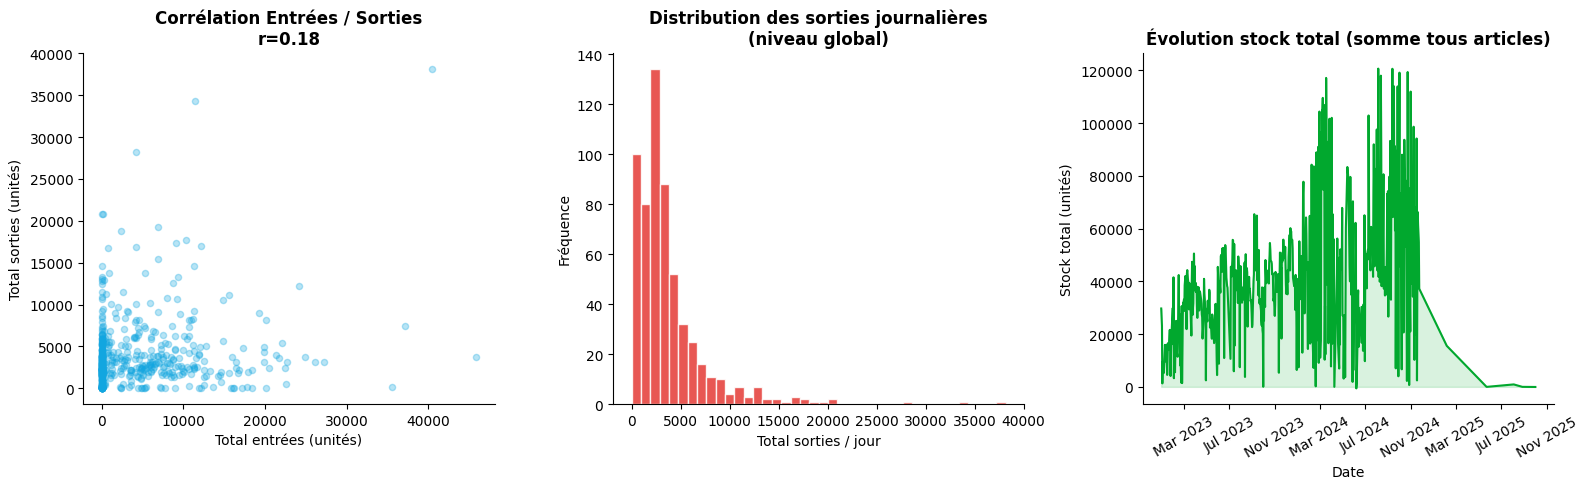

In [16]:
# ── Cellule E : Corrélation et relation entrées-sorties ───────
# Très important pour l'encadrant — montre la cohérence des données

corr_data = (
    df_raw.groupby('DateJour')
    .agg(
        entrees=  ('TotalEntree',  'sum'),
        sorties=  ('TotalSortie',  'sum'),
        val_ent=  ('ValeurEntree', 'sum'),
        val_sor=  ('ValeurSortie', 'sum'),
        stock=    ('StockFinal',   'sum')
    )
    .reset_index()
)

correlation_qte = corr_data['entrees'].corr(corr_data['sorties'])
correlation_val = corr_data['val_ent'].corr(corr_data['val_sor'])

print(f"Corrélation Entrées/Sorties (quantité) : {correlation_qte:.3f}")
print(f"Corrélation ValEntree/ValSortie        : {correlation_val:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Scatter entrées vs sorties
axes[0].scatter(corr_data['entrees'], corr_data['sorties'],
                alpha=0.3, color='#12a6e0', s=20)
axes[0].set_title(f'Corrélation Entrées / Sorties\nr={correlation_qte:.2f}',
                  fontweight='bold')
axes[0].set_xlabel("Total entrées (unités)")
axes[0].set_ylabel("Total sorties (unités)")

# Distribution des sorties journalières
axes[1].hist(corr_data['sorties'], bins=40,
             color='#e53935', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution des sorties journalières\n(niveau global)',
                  fontweight='bold')
axes[1].set_xlabel("Total sorties / jour")
axes[1].set_ylabel("Fréquence")

# Stock global dans le temps
axes[2].fill_between(corr_data['DateJour'], corr_data['stock'],
                     alpha=0.15, color='#01a82e')
axes[2].plot(corr_data['DateJour'], corr_data['stock'],
             color='#01a82e', linewidth=1.5)
axes[2].set_title('Évolution stock total (somme tous articles)',
                  fontweight='bold')
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Stock total (unités)")
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig(f'../outputs/{BASE_NAME}_09_correlations.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# ── Cellule F : Résumé final enrichi pour l'encadrant ─────────
print("=" * 65)
print(f"  RAPPORT D'EXPLORATION COMPLET — {BASE_NAME}")
print("=" * 65)

print(f"""
┌─────────────────────────────────────────────────────────┐
│  STRUCTURE DES DONNÉES                                  │
├─────────────────────────────────────────────────────────┤
│  Colonnes              : {len(df_raw.columns):<5}                          │
│  Lignes totales        : {len(df_raw):<10,}                     │
│  Articles uniques      : {df_raw['AR_Ref'].nunique():<5}                          │
│  Dépôts uniques        : {df_raw['DE_No'].nunique():<5}                          │
│  Familles              : {df_raw['FA_Intitule'].nunique():<5}                          │
│  Catalogues N1         : {df_raw['CL_Intitule1'].nunique():<5}                          │
├─────────────────────────────────────────────────────────┤
│  COUVERTURE TEMPORELLE                                  │
├─────────────────────────────────────────────────────────┤
│  Début                 : {str(df_raw['DateJour'].min().date()):<12}                   │
│  Fin                   : {str(df_raw['DateJour'].max().date()):<12}                   │
│  Durée totale          : {(df_raw['DateJour'].max() - df_raw['DateJour'].min()).days:<5} jours calendrier        │
│  Jours avec mouvement  : {df_raw['DateJour'].nunique():<5}                          │
├─────────────────────────────────────────────────────────┤
│  VOLUMES                                                │
├─────────────────────────────────────────────────────────┤
│  Total sorties (unités): {df_raw['TotalSortie'].sum():<15,.0f}              │
│  Valeur sorties (MAD)  : {df_raw['ValeurSortie'].sum():<15,.2f}              │
│  Total entrées (unités): {df_raw['TotalEntree'].sum():<15,.0f}              │
│  Valeur entrées (MAD)  : {df_raw['ValeurEntree'].sum():<15,.2f}              │
├─────────────────────────────────────────────────────────┤
│  MACHINE LEARNING                                       │
├─────────────────────────────────────────────────────────┤
│  Articles prévisibles  : {len(articles_previsibles):<5} / {df_raw['AR_Ref'].nunique():<5}                    │
│  Modèle choisi         : Prophet (Meta)                 │
│  Horizon prévision     : 30 jours                       │
│  Saisonnalité          : hebdo + mensuelle + annuelle   │
├─────────────────────────────────────────────────────────┤
│  ALERTES                                                │
├─────────────────────────────────────────────────────────┤
│  Articles risque rupture : {len(articles_risque):<5}                        │
│  Stock min observé (qte) : {stock_analyse['stock_min'].min():<10,.0f}               │
└─────────────────────────────────────────────────────────┘
""")

# Qualité des données
nulls_total = df_raw.isnull().sum().sum()
print(f"✅ Qualité des données : {'Excellente' if nulls_total == 0 else f'{nulls_total} valeurs manquantes'}")
print(f"✅ Valeurs négatives TotalSortie : {(df_raw['TotalSortie'] < 0).sum()}")
print(f"✅ Valeurs négatives StockFinal  : {(df_raw['StockFinal']  < 0).sum()}")
print(f"✅ Doublons (AR_Ref+DE_No+Date)  : {df_raw.duplicated(['AR_Ref','DE_No','DateJour']).sum()}")

# Sauvegardes
df_raw.to_parquet(f'../outputs/{BASE_NAME}_raw.parquet', index=False)
articles_previsibles.to_csv(f'../outputs/{BASE_NAME}_articles_previsibles.csv', index=False)
depot_stats.to_csv(f'../outputs/{BASE_NAME}_depot_stats.csv', index=False)
famille_stats.to_csv(f'../outputs/{BASE_NAME}_famille_stats.csv', index=False)

print(f"\n✅ Tous les fichiers sauvegardés dans outputs/")
print(f"\n➡️  PRÊT pour notebook 02_preprocessing.ipynb")

  RAPPORT D'EXPLORATION COMPLET — STE_NGDM

┌─────────────────────────────────────────────────────────┐
│  STRUCTURE DES DONNÉES                                  │
├─────────────────────────────────────────────────────────┤
│  Colonnes              : 21                             │
│  Lignes totales        : 16,972                         │
│  Articles uniques      : 278                            │
│  Dépôts uniques        : 12                             │
│  Familles              : 38                             │
│  Catalogues N1         : 11                             │
├─────────────────────────────────────────────────────────┤
│  COUVERTURE TEMPORELLE                                  │
├─────────────────────────────────────────────────────────┤
│  Début                 : 2022-12-31                     │
│  Fin                   : 2025-10-01                     │
│  Durée totale          : 1005  jours calendrier        │
│  Jours avec mouvement  : 586                           